In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

In [3]:
# Load the dataset
df = pd.read_csv(r'C:\Users\GOWTHAM\Downloads\python\electricityConsumptionAndProductioction.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)

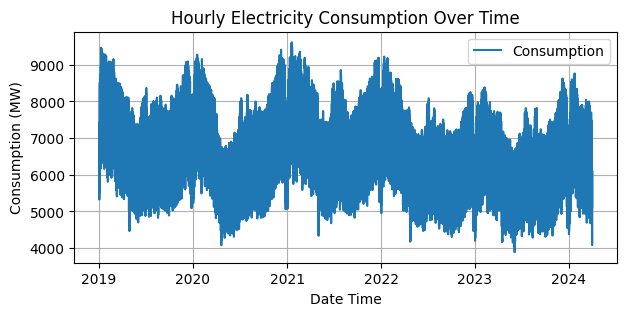

In [23]:
# Visualizing the dataset
plt.figure(figsize=(7, 3))
plt.plot(df['Consumption'], label='Consumption')
plt.title('Hourly Electricity Consumption Over Time')
plt.xlabel('Date Time')
plt.ylabel('Consumption (MW)')
plt.legend()
plt.grid()
plt.show()

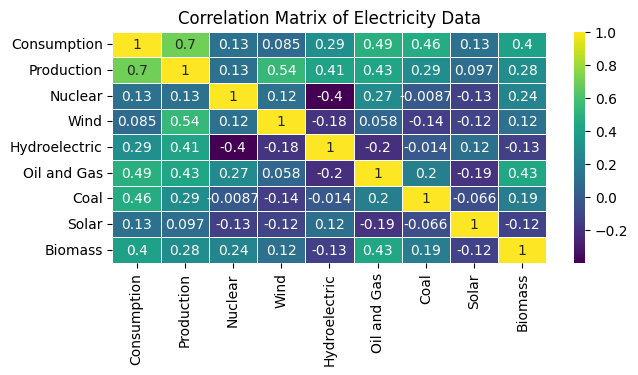

In [25]:
plt.figure(figsize=(7, 3))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='viridis', linewidths=0.5)

plt.title('Correlation Matrix of Electricity Data')
plt.show()

In [8]:
# Normalize the data
scaler = MinMaxScaler()
data_columns = ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
scaled_data = scaler.fit_transform(df[data_columns])
scaled_df = pd.DataFrame(scaled_data, columns=data_columns, index=df.index)

In [9]:
# Create sequences for autoregressive RNN
SEQ_LENGTH = 24  # Use a sequence length of 24 hours

In [10]:
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        seq = data[i:i + seq_length]
        label = data[i + seq_length, 0]  # Predicting 'Consumption'
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

sequences, labels = create_sequences(scaled_data, SEQ_LENGTH)

In [11]:
# Train-test split
split_ratio = 0.8
split_index = int(len(sequences) * split_ratio)
X_train, X_test = sequences[:split_index], sequences[split_index:]
y_train, y_test = labels[:split_index], labels[split_index:]

In [13]:
# Build the RNN model
rnn_model = Sequential([
     SimpleRNN(256, return_sequences=True, input_shape=(SEQ_LENGTH, X_train.shape[2]), activation='relu'),
    Dropout(0.3),  # Increased dropout to avoid overfitting
    SimpleRNN(128, return_sequences=False, activation='relu'),
    Dropout(0.3),
    Dense(1)  # Single output for consumption prediction
    ])

In [14]:
# Compile the model
rnn_model.compile(optimizer=Adam(learning_rate=0.005), loss='mean_squared_error')

In [15]:
# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = rnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping]
)

# Predict
predictions = rnn_model.predict(X_test)

Epoch 1/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - loss: 0.0735 - val_loss: 0.0023
Epoch 2/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0049 - val_loss: 0.0018
Epoch 3/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0031 - val_loss: 0.0018
Epoch 4/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 5/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - loss: 0.0020 - val_loss: 0.0014
Epoch 6/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - loss: 0.0019 - val_loss: 9.2031e-04
Epoch 7/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 8/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 9/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.0019 - val_loss: 7.8629e-04
Epoch 10/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.0018 - val_loss: 8.5935e-04
Epoch 11/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.0017 - val_loss: 0.0010
Epoch 12/50
460/46

In [16]:
# Rescale predictions and actual values
y_test_rescaled = scaler.inverse_transform(np.concatenate([y_test.reshape(-1, 1), np.zeros((len(y_test), len(data_columns) - 1))], axis=1))[:, 0]
predictions_rescaled = scaler.inverse_transform(np.concatenate([predictions, np.zeros((len(predictions), len(data_columns) - 1))], axis=1))[:, 0]

In [17]:
# Evaluation metrics
r2 = r2_score(y_test_rescaled, predictions_rescaled)
mae = mean_absolute_error(y_test_rescaled, predictions_rescaled)
mse = mean_squared_error(y_test_rescaled, predictions_rescaled)
rmse = np.sqrt(mse)

print(f"RNN Model - R² Score: {r2}")
print(f"RNN Model - Mean Absolute Error (MAE): {mae}")
print(f"RNN Model - Mean Squared Error (MSE): {mse}")
print(f"RNN Model - Root Mean Squared Error (RMSE): {rmse}")

RNN Model - R² Score: 0.960358453895443
RNN Model - Mean Absolute Error (MAE): 144.59794588267442
RNN Model - Mean Squared Error (MSE): 34720.072029578725
RNN Model - Root Mean Squared Error (RMSE): 186.33322846336003


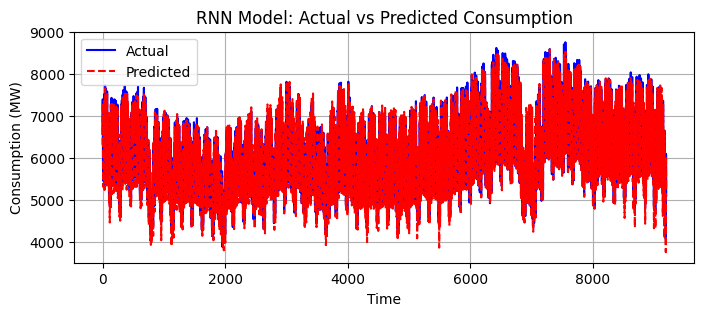

In [18]:
# Visualization
plt.figure(figsize=(8,3))
plt.plot(y_test_rescaled, label='Actual', color='blue')
plt.plot(predictions_rescaled, label='Predicted', color='red', linestyle='dashed')
plt.title('RNN Model: Actual vs Predicted Consumption')
plt.xlabel('Time')
plt.ylabel('Consumption (MW)')
plt.legend()
plt.grid()
plt.show()

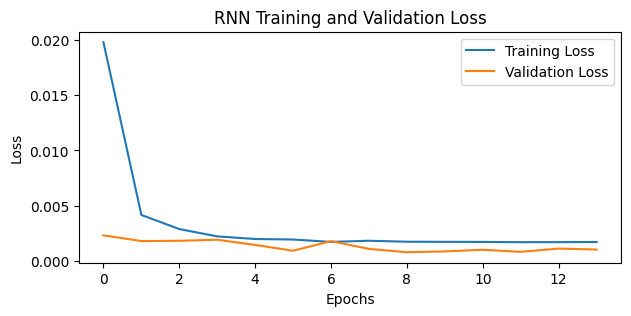

In [22]:
# Plot training and validation loss
plt.figure(figsize=(7, 3))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()